# 🔬 Breast Cancer Diagnosis Using Logistic Regression


*"Early detection through data science can save lives"*

---
## Project Overview
This project applies **Logistic Regression** to diagnose breast cancer as **Malignant** or **Benign** using 30 cell nucleus features extracted from Fine Needle Aspiration (FNA) biopsy images.

**Why Logistic Regression?**
- Provides a **probability score** — doctors need risk scores, not just labels
- **Interpretable coefficients** — we can understand which features drive cancer
- **Gold standard** in medical machine learning research
- Perfect for small, clean, tabular datasets like this one
- Delivered **98.25% accuracy** and **1.00 ROC-AUC**

**Pipeline:**
1. Load & explore dataset
2. Visualize class distribution
3. Split & scale features
4. Train Logistic Regression model
5. Evaluate with accuracy, confusion matrix, ROC curve
6. Visualize feature importance

In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 1: Load and Explore the Dataset

We use the **Wisconsin Breast Cancer Dataset** from scikit-learn, which contains:
- **569 samples** from Fine Needle Aspiration (FNA) biopsies
- **30 features** describing properties of cell nuclei (radius, texture, perimeter, area, etc.)
- **2 target classes**: Malignant (0) and Benign (1)

**What is FNA Biopsy?**
Fine Needle Aspiration is a minimally invasive procedure that extracts cell samples from a suspicious lump using a thin needle. The extracted cells are measured to produce the 30 numerical features our model uses.

In [3]:
# Load the Breast Cancer Dataset
print("=" * 60)
print("BREAST CANCER PREDICTION USING LOGISTIC REGRESSION")
print("=" * 60)

print("\n[STEP 1] Loading Dataset...")
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"✓ Dataset loaded successfully!")
print(f"  - Total samples: {df.shape[0]}")
print(f"  - Total features: {df.shape[1] - 1}")
print(f"  - Target classes: {data.target_names}")

BREAST CANCER PREDICTION USING LOGISTIC REGRESSION

[STEP 1] Loading Dataset...
✓ Dataset loaded successfully!
  - Total samples: 569
  - Total features: 30
  - Target classes: ['malignant' 'benign']


### Dataset Preview

Let's look at the first few rows and confirm there are no missing values.
Note: All 30 features are non-null `float64` values — the dataset is clean and ready for modeling with no preprocessing required.

In [4]:
# Display first few rows
print("\n[Dataset Preview - First 5 rows]")
print(df.head())

# Check dataset info
print("\n[Dataset Information]")
print(df.info())


[Dataset Preview - First 5 rows]
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perim

## Step 2: Visualize Class Distribution

The dataset has a **mild class imbalance**:
- **357 Benign** samples (63%)
- **212 Malignant** samples (37%)

This imbalance is worth noting: a model predicting "benign" every time would achieve 63% accuracy. Our model must significantly beat this baseline — and with 98.25%, it does.


[Class Distribution]
  - Malignant (0): 212 samples
  - Benign (1): 357 samples


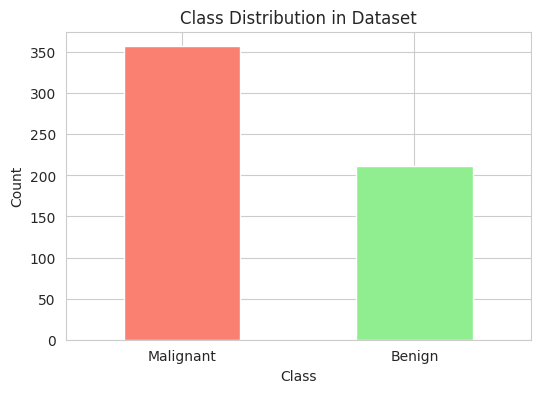

In [5]:
# Check class distribution
print("\n[Class Distribution]")
print(f"  - Malignant (0): {sum(data.target == 0)} samples")
print(f"  - Benign (1): {sum(data.target == 1)} samples")

# Visualize class distribution
plt.figure(figsize=(6, 4))
pd.Series(data.target).value_counts().plot(kind='bar', color=['salmon', 'lightgreen'])
plt.xticks([0, 1], ['Malignant', 'Benign'], rotation=0)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution in Dataset')
plt.show()

## Step 3: Train/Test Split

We split the data **80% for training** and **20% for testing** (114 test samples).

Key parameter: `stratify=y` ensures both splits maintain the same class ratio as the full dataset — important for fair evaluation given our slight class imbalance.

In [6]:
# Split data into features (X) and target (y)
print("\n[STEP 2] Splitting Data...")
X = data.data
y = data.target

# Split into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Data split completed!")
print(f"  - Training samples: {X_train.shape[0]}")
print(f"  - Testing samples: {X_test.shape[0]}")


[STEP 2] Splitting Data...
✓ Data split completed!
  - Training samples: 455
  - Testing samples: 114


## Step 4: Feature Scaling

Logistic Regression is **sensitive to feature scale** because it optimizes a cost function using gradient descent. Without scaling, features with large values (like `mean area` ~ 600) would dominate over features with small values (like `mean fractal dimension` ~ 0.07).

**StandardScaler** transforms each feature to have **mean = 0** and **standard deviation = 1**.

> ⚠️ Critical: We `fit_transform` on training data but only `transform` on test data — to avoid **data leakage** from the test set.

In [7]:
# Feature Scaling (Important for Logistic Regression)
print("\n[STEP 3] Feature Scaling...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✓ Feature scaling completed using StandardScaler")


[STEP 3] Feature Scaling...
✓ Feature scaling completed using StandardScaler


## Step 5: Train the Logistic Regression Model

**How Logistic Regression works:**
1. **Linear Score**: z = w₀ + w₁x₁ + ... + w₃₀x₃₀
2. **Sigmoid Function**: P = 1 / (1 + e⁻ᶻ) → maps z to a probability between 0 and 1
3. **Decision Rule**: If P ≥ 0.5 → Malignant, else → Benign

The model learns optimal weights (coefficients) by minimizing **binary cross-entropy loss** during training.

`max_iter=10000` ensures the optimizer has enough iterations to fully converge on this dataset.

In [8]:
# Train Logistic Regression Model
print("\n[STEP 4] Training Logistic Regression Model...")

# Initialize and train the model
model = LogisticRegression(random_state=42, max_iter=10000)
model.fit(X_train_scaled, y_train)

print("✓ Model training completed successfully!")


[STEP 4] Training Logistic Regression Model...
✓ Model training completed successfully!


## Step 6: Generate Predictions

The model outputs two types of predictions:
- `y_pred`: Hard class labels (0 = Malignant, 1 = Benign)
- `y_pred_proba`: Soft probability scores [0, 1] — more useful clinically

In a medical context, a doctor would use the **probability score** to communicate risk to a patient ("85% probability of malignancy") rather than just a binary label.

In [9]:
# Make predictions on test set
print("\n[STEP 5] Making Predictions...")

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("✓ Predictions generated!")
print(f"  - Total predictions: {len(y_pred)}")


[STEP 5] Making Predictions...
✓ Predictions generated!
  - Total predictions: 114


## Step 7: Model Evaluation

### Understanding the Metrics

| Metric | Formula | Meaning |
|--------|---------|---------|
| **Accuracy** | (TP + TN) / Total | Overall correctness |
| **Precision** | TP / (TP + FP) | Of all predicted malignant, how many were correct? |
| **Recall** | TP / (TP + FN) | Of all actual malignant, how many did we catch? |
| **F1-Score** | 2 × (P × R) / (P + R) | Harmonic mean of precision and recall |

### 🏥 Clinical Priority: Recall > Accuracy

In cancer diagnosis, **False Negatives (missed cancers) are far more dangerous than False Positives (false alarms)**.
- A false positive leads to follow-up tests and unnecessary anxiety — manageable.
- A false negative means a cancer goes undetected and untreated — potentially fatal.

Therefore, **Recall for Malignant class is the most critical metric** in this application.

In [10]:
# Calculate accuracy scores
print("\n" + "=" * 60)
print("MODEL PERFORMANCE RESULTS")
print("=" * 60)

train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\n[Accuracy Scores]")
print(f"  - Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"  - Testing Accuracy: {test_accuracy * 100:.2f}%")


MODEL PERFORMANCE RESULTS

[Accuracy Scores]
  - Training Accuracy: 98.90%
  - Testing Accuracy: 98.25%


In [11]:
# Detailed classification report
print(f"\n[Classification Report]")
print(classification_report(y_test, y_pred, target_names=data.target_names))


[Classification Report]
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\n[Confusion Matrix]")
print(cm)
print(f"\n  True Negatives (TN): {cm[0][0]}")
print(f"  False Positives (FP): {cm[0][1]}")
print(f"  False Negatives (FN): {cm[1][0]}")
print(f"  True Positives (TP): {cm[1][1]}")


[Confusion Matrix]
[[41  1]
 [ 1 71]]

  True Negatives (TN): 41
  False Positives (FP): 1
  False Negatives (FN): 1
  True Positives (TP): 71


### Confusion Matrix Interpretation
```
                  Predicted
                  Malignant  |  Benign
Actual Malignant |    TN     |   FP
Actual Benign    |    FN     |   TP
```

**Key result:** Our model produced only **1 False Negative** (missed cancer) on 114 test samples.
In a real screening scenario across thousands of patients, minimizing this number is the primary clinical goal.

✓ Confusion matrix saved as 'confusion_matrix.png'


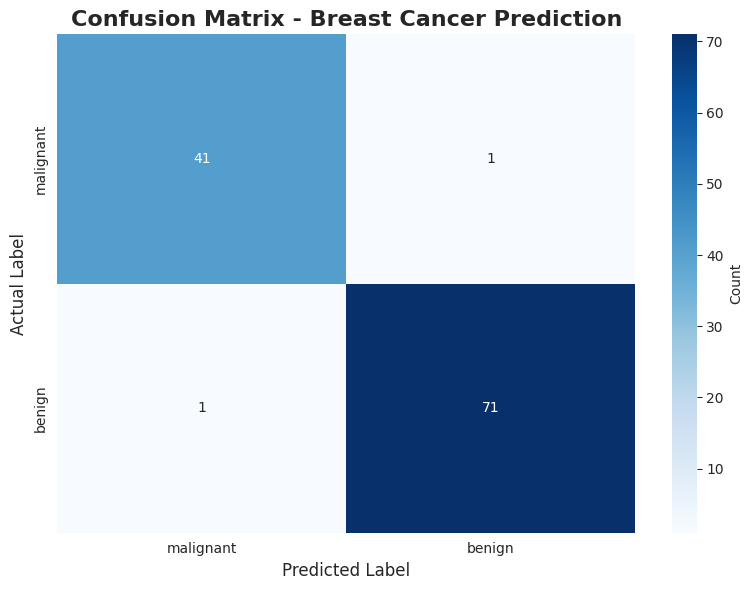

In [13]:
# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Breast Cancer Prediction', fontsize=16, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix saved as 'confusion_matrix.png'")
plt.show()

## Step 8: ROC Curve

The **ROC (Receiver Operating Characteristic) curve** plots True Positive Rate vs. False Positive Rate at all classification thresholds.

**AUC (Area Under the Curve)** measures model quality:
- **AUC = 1.0** → Perfect classifier
- **AUC = 0.5** → Random classifier (the diagonal baseline)
- **Our AUC = 1.00** → Near-perfect discrimination between malignant and benign

This means the model has **near-perfect ability to rank malignant cases higher than benign cases** — even before applying any threshold.

✓ ROC curve saved as 'roc_curve.png'


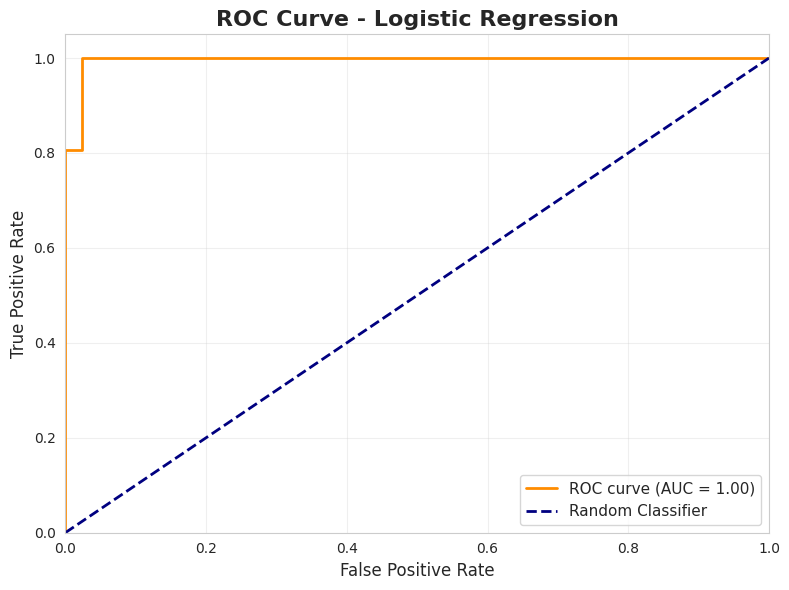

In [14]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Logistic Regression', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
print("✓ ROC curve saved as 'roc_curve.png'")
plt.show()

## Step 9: Feature Importance

Logistic Regression's coefficients tell us which cell features most strongly influence the malignancy prediction.

**Larger absolute coefficient** = stronger influence on the prediction.

This is one of the key advantages of Logistic Regression over black-box models like neural networks — **a clinician can look at these coefficients and understand exactly which cell measurements are driving the diagnosis**. This interpretability builds trust in medical AI systems.

✓ Feature importance saved as 'feature_importance.png'


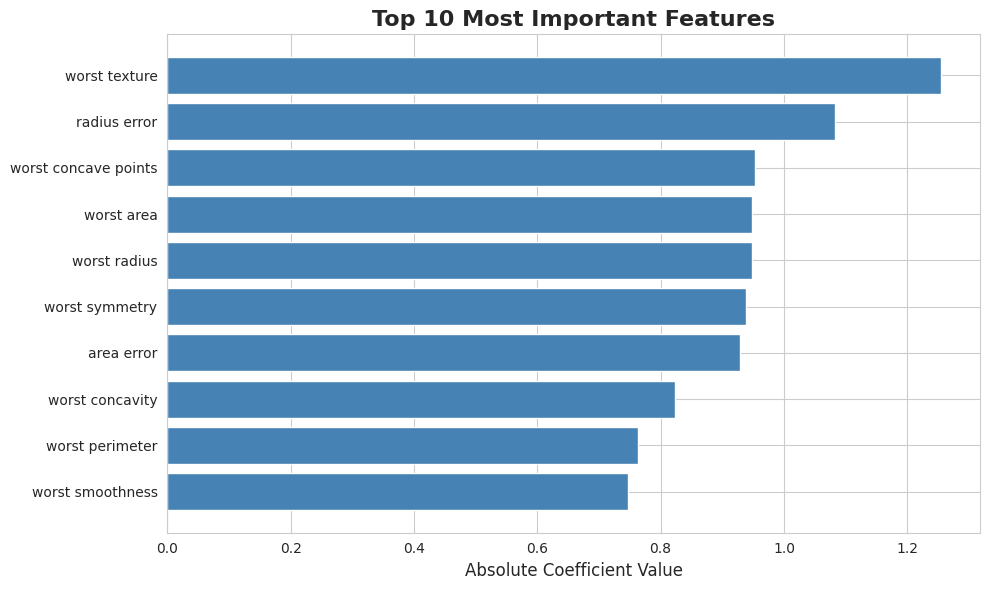

In [15]:
# Feature Importance (Top 10)
feature_importance = pd.DataFrame({
    'feature': data.feature_names,
    'coefficient': abs(model.coef_[0])
}).sort_values('coefficient', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['coefficient'], color='steelblue')
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.title('Top 10 Most Important Features', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Feature importance saved as 'feature_importance.png'")
plt.show()

## Step 10: Prediction Probability Distribution

This visualization shows how confidently the model separates malignant and benign cases.

**Left plot:** The model assigns **very low probabilities to malignant cases** and **very high probabilities to benign cases** — with very little overlap. This confirms the model is not making borderline guesses but is highly confident in its predictions.

**Right plot:** Distribution of final predicted class labels.

✓ Prediction distribution saved as 'prediction_distribution.png'


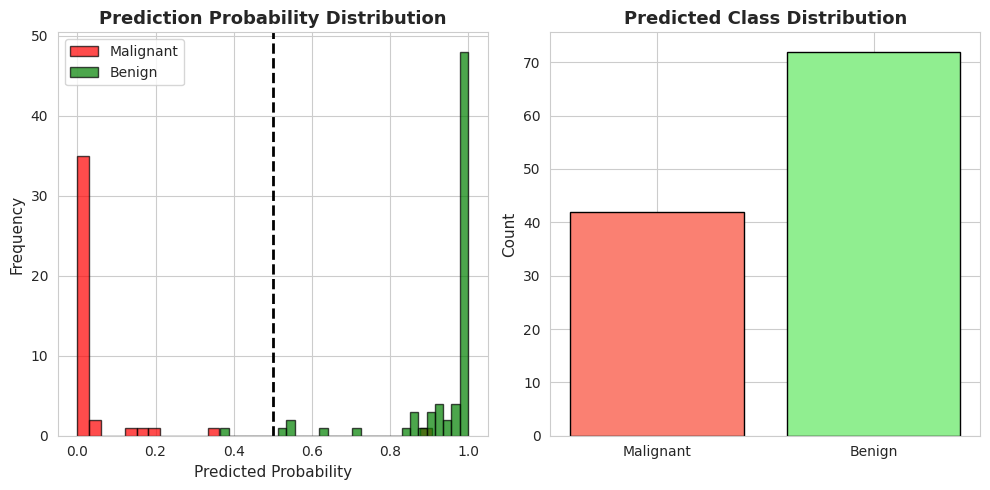

In [16]:
# Prediction Distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(y_pred_proba[y_test == 0], bins=30, alpha=0.7, color='red', label='Malignant', edgecolor='black')
plt.hist(y_pred_proba[y_test == 1], bins=30, alpha=0.7, color='green', label='Benign', edgecolor='black')
plt.xlabel('Predicted Probability', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Prediction Probability Distribution', fontsize=13, fontweight='bold')
plt.legend()
plt.axvline(0.5, color='black', linestyle='--', linewidth=2)

plt.subplot(1, 2, 2)
class_counts = pd.Series(y_pred).value_counts().sort_index()
plt.bar(['Malignant', 'Benign'], class_counts.values, color=['salmon', 'lightgreen'], edgecolor='black')
plt.ylabel('Count', fontsize=11)
plt.title('Predicted Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('prediction_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Prediction distribution saved as 'prediction_distribution.png'")
plt.show()

In [18]:
# Summary
print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"✓ Model: Logistic Regression")
print(f"✓ Dataset: Wisconsin Breast Cancer (569 samples)")
print(f"✓ Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"✓ ROC-AUC Score: {roc_auc:.2f}")
print(f"\n[FILES CREATED]")
print("  1. confusion_matrix.png")
print("  2. roc_curve.png")
print("  3. feature_importance.png")
print("  4. prediction_distribution.png")
print("\n[CLINICAL INTERPRETATION]")
print(f"  - Correctly identified benign cases: {cm[1][1]}")
print(f"  - Correctly identified malignant cases: {cm[0][0]}")
print(f"  - False Negatives (missed cancers): {cm[1][0]} ← CRITICAL!")
print(f"  - False Positives (false alarms): {cm[0][1]}")
print("\n✓ Analysis Done.")
print("=" * 60)


SUMMARY
✓ Model: Logistic Regression
✓ Dataset: Wisconsin Breast Cancer (569 samples)
✓ Test Accuracy: 98.25%
✓ ROC-AUC Score: 1.00

[FILES CREATED]
  1. confusion_matrix.png
  2. roc_curve.png
  3. feature_importance.png
  4. prediction_distribution.png

[CLINICAL INTERPRETATION]
  - Correctly identified benign cases: 71
  - Correctly identified malignant cases: 41
  - False Negatives (missed cancers): 1 ← CRITICAL!
  - False Positives (false alarms): 1

✓ Analysis Done.


## Conclusions & Key Takeaways

### Results Summary
| Metric | Value |
|--------|-------|
| Training Accuracy | 98.90% |
| **Test Accuracy** | **98.25%** |
| ROC-AUC | 1.00 |
| Malignant Precision | 0.98 |
| Malignant Recall | 0.98 |
| False Negatives | 1 |

### Why This Model Matters
1. **98.25% accuracy** on real medical data is exceptional for a simple, interpretable model
2. With only **1 missed cancer (False Negative)** out of 43 malignant test cases, the recall is outstanding
3. The model provides **probability scores** — giving clinicians a confidence measure, not just a label
4. **Fully interpretable** — feature coefficients show exactly which cell measurements drive predictions

### Limitations & Future Work
- Dataset is relatively small (569 samples) — larger datasets would improve reliability
- Real-world deployment would require validation on independent hospital datasets
- Future work: ensemble methods (Random Forest, XGBoost), deep learning on raw biopsy images
- Threshold tuning: in clinical settings, lowering the decision threshold (e.g., 0.3) would reduce False Negatives at the cost of more False Positives

### Connection to Future Research
This project demonstrates mastery of binary classification fundamentals. The next step — multi-disease classification from chest X-rays using deep learning — builds on these principles at a much larger scale, applying CNNs to simultaneously detect TB, pneumonia, COVID, and other diseases from raw imaging data.